In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# These help us create polynomial features and linear regression models
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# This helps us split data into training and testing sets
from sklearn.model_selection import train_test_split

# This helps us measure model performance
from sklearn.metrics import mean_squared_error


Degree 1 Model
Training Error: 61.67468175388966
Testing Error: 32.224585824919124

Degree 2 Model
Training Error: 1.4875662784167652e-29
Testing Error: 1.2884728118609859e-29

Degree 9 Model
Training Error: 2.012680179412724e-22
Testing Error: 1.9082716334278385


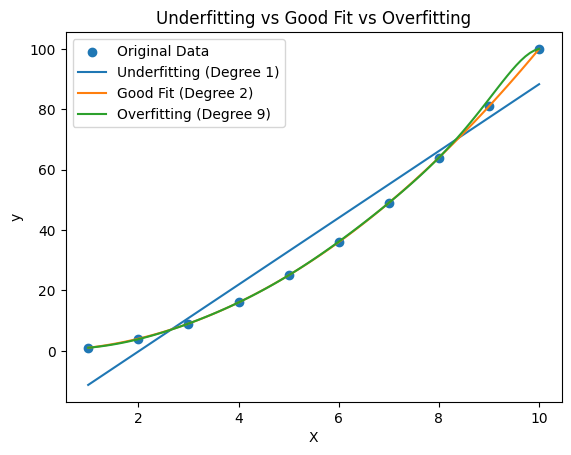

In [2]:
# Step 1: Create sample data
# X = input values
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)

# y = output values
# This data has a curved pattern, not a perfectly straight line
y = np.array([1, 4, 9, 16, 25, 36, 49, 64, 81, 100])


# Step 2: Split data into training and testing data
# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# Function to train and evaluate a polynomial regression model
def evaluate_model(degree):
    # Convert input X into polynomial features
    # degree=1  -> simple straight line
    # degree=2  -> curve
    # degree=9  -> very complex curve
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create model
    model = LinearRegression()

    # Train model
    model.fit(X_train_poly, y_train)

    # Predict on training and testing data
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate training and testing error
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    print(f"\nDegree {degree} Model")
    print("Training Error:", train_error)
    print("Testing Error:", test_error)

    return model, poly


# Step 3: Underfitting model
# Degree 1 = simple line, may not capture curve properly
underfit_model, underfit_poly = evaluate_model(degree=1)

# Step 4: Good fit model
# Degree 2 = matches curved pattern better
goodfit_model, goodfit_poly = evaluate_model(degree=2)

# Step 5: Overfitting model
# Degree 9 = very complex model, may memorize training data
overfit_model, overfit_poly = evaluate_model(degree=9)


# Step 6: Plot all three models
# Generate smooth X values for plotting curves
X_plot = np.linspace(1, 10, 100).reshape(-1, 1)

# Convert plot X values for each model
X_plot_underfit = underfit_poly.transform(X_plot)
X_plot_goodfit = goodfit_poly.transform(X_plot)
X_plot_overfit = overfit_poly.transform(X_plot)

# Predict smooth curves
y_plot_underfit = underfit_model.predict(X_plot_underfit)
y_plot_goodfit = goodfit_model.predict(X_plot_goodfit)
y_plot_overfit = overfit_model.predict(X_plot_overfit)


# Plot original data
plt.scatter(X, y, label="Original Data")

# Plot underfitting model
plt.plot(X_plot, y_plot_underfit, label="Underfitting (Degree 1)")

# Plot good fit model
plt.plot(X_plot, y_plot_goodfit, label="Good Fit (Degree 2)")

# Plot overfitting model
plt.plot(X_plot, y_plot_overfit, label="Overfitting (Degree 9)")

# Add labels and title
plt.xlabel("X")
plt.ylabel("y")
plt.title("Underfitting vs Good Fit vs Overfitting")
plt.legend()

# Show plot
plt.show()